## Problema - Crecimiento de suscriptores en una plataforma de streaming

In [4]:
# @title Ingrese datos
nombre_estudiante = "Daniel Felipe Cardenas Romero" # @param {"type":"string"}
carnet = 1000110894 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

El problema nos pide analizar y predecir el crecimiento de los nuevos usuarios en una plataforma de streaming. Sabemos que el comportamiento sigue una secuencia donde el mes 0 registró 0 usuarios y el mes 1 registró 1 usuario. Para cualquier mes a partir del segundo, el número de suscriptores nuevos es exactamente la suma de los nuevos usuarios de los dos meses anteriores, esto por el efecto de referidos y recomendaciones. El objetivo es programar este cálculo usando memoización para evitar lentitud al consultar meses lejanos.

## 2) Requerimientos **[2 pts]**
### Requerimientos Funcionales:
- Recepción de parámetros: El sistema debe admitir un valor entero positivo n que represente el mes a consultar en la plataforma de streaming.
- Cálculo de casos base: Si el mes ingresado es n=0, el sistema debe retornar 0 usuarios; si es n=1, debe retornar 1 usuario.
- Cálculo por recurrencia: Para cualquier mes n, el sistema debe calcular los nuevos usuarios sumando exactamente los resultados de los meses n-1 y n-2.
- Memoización : El sistema debe guardar temporalmente los resultados de cada mes calculado en una estructura de datos tipo mapa para evitar volver a calcular problemas superpuestos.
- Validación de entrada: El sistema debe aceptar únicamente números enteros no negativos como entrada para el mes n.

### Requerimientos No Funcionales
- Rendimiento: El algoritmo debe garantizar un tiempo de ejecución lineal O(n), eliminando la complejidad exponencial.
- Eficiencia del Espacio: El consumo de memoria estructural no debe superar O(n), manteniendo el almacenamiento de las variables ligado al número de meses consultados.
- Escalabilidad: El programa debe ser capaz de procesar meses relativamente grandes (ej. n=100) en fracciones de segundo sin errores.
- Tecnología: El código debe estar desarrollado en Python.

## 3) Historias de usuario **[2 pts]**
-HU1: Validación de inicio de la plataforma
Como administrador de la plataforma, quiero consultar los meses base (0 y 1) para confirmar el inicio de los registros de la empresa y asegurar que los cálculos partan de los valores correctos.

-Criterios de Aceptación:
Si se ingresa el mes 0, la función debe devolver exactamente 0.
Si se ingresa el mes 1, la función debe devolver exactamente 1.

-HU2: Proyección de crecimiento por referidos
Como analista de crecimiento, quiero consultar el número de suscriptores nuevos para un mes n, para visualizar cómo el efecto combinado de recomendaciones está impactando las métricas mensuales.

-Criterios de Aceptación:
El sistema debe retornar un valor entero correspondiente a la suma de los dos meses previos.
El resultado debe ser matemáticamente exacto según la sucesión de Fibonacci.

-HU3: Optimización del sistema mediante caché
Como desarrollador, quiero que el sistema guarde en memoria los cálculos que ya se han hecho en el proceso recursivo, para que el servidor no se quede congelado repitiendo ramas lógicas.

-Criterios de Aceptación:
La función debe revisar obligatoriamente si el mes ya existe en el diccionario antes de hacer una nueva llamada recursiva.
Al calcular un mes alto, el tiempo de ejecución debe ser menor a 1 segundo.

## 4) Diagramas de flujo **[5 pts]**
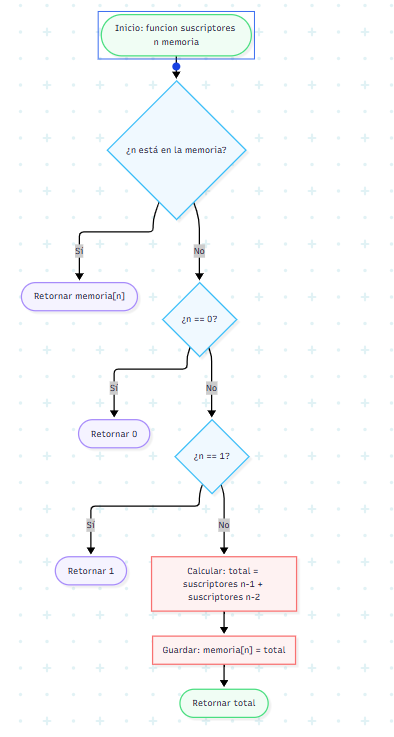

Descripcion:
Se inicia comprobando si ya se guardó el resultado de n en la lista de memoizacion, si es asi se retorna ese valor ya que previamente estaba solucionado, de lo contrario se validan casos base, si n=0 entonces retornamos 0, si n=1 entonces retornamos 1, de lo contrario ya se calcula gracias a la función: el valor de n (p(n-1)+p(n-2)), guarda en memo y se retorna la solucion.

### 5) Análisis de complejidad **[15 pts]**
-Justificación: Al implementar T(n) = T(n-1) + T(n-2) de manera recursiva pura, el sistema crearía un árbol de subproblemas superpuestos. Esto significa que recalcularía las mismas ramas muchísimas veces, siendo una complejidad exponencial de O(2^n). 
Al aplicar programación dinámica (Top-Down) a través de la memoización, se poda este árbol. Cada mes se calcula una sola vez. Una vez hallado el valor, se almacena en un diccionario. Cuando el algoritmo necesita un mes ya procesado, simplemente lo busca en el diccionario.

Función T[n]:
T(n) = T(n-1) + T(n-2) para todo n >= 2
con T(0)=0 y T(1)=1

-Complejidad de Tiempo: O(n). 
Para un mes n, el algoritmo resuelve un total de n subproblemas únicos. Cada subproblema realiza una verificación en el diccionario, una suma y una inserción; todas estas son operaciones de tiempo constante O(1). Al multiplicar n veces O(1), da un tiempo lineal

-Complejidad de Espacio: O(n). 
El espacio extra consumido proviene de dos fuentes: 
1) El diccionario de memoización que almacenará n pares de clave-valor. 
2) La profundidad máxima de la pila de llamadas (Call Stack) que el sistema operativo debe reservar durante las llamadas recursivas, la cual desciende hasta un nivel n. Ambas estructuras crecen de forma directamente proporcional al tamaño del problema.

### Mejor caso y Peor caso:

-Mejor caso: \Omega(1) (Tiempo constante). Se da en dos situaciones: 
cuando se solicita directamente un caso base (n=0 o n=1), o cuando se solicita un mes n que ya fue calculado en una ejecución anterior y está presente en el diccionario de memoria. En estos casos, el algoritmo simplemente retorna el valor directo sin realizar sumas ni entrar en nuevas recursiones.
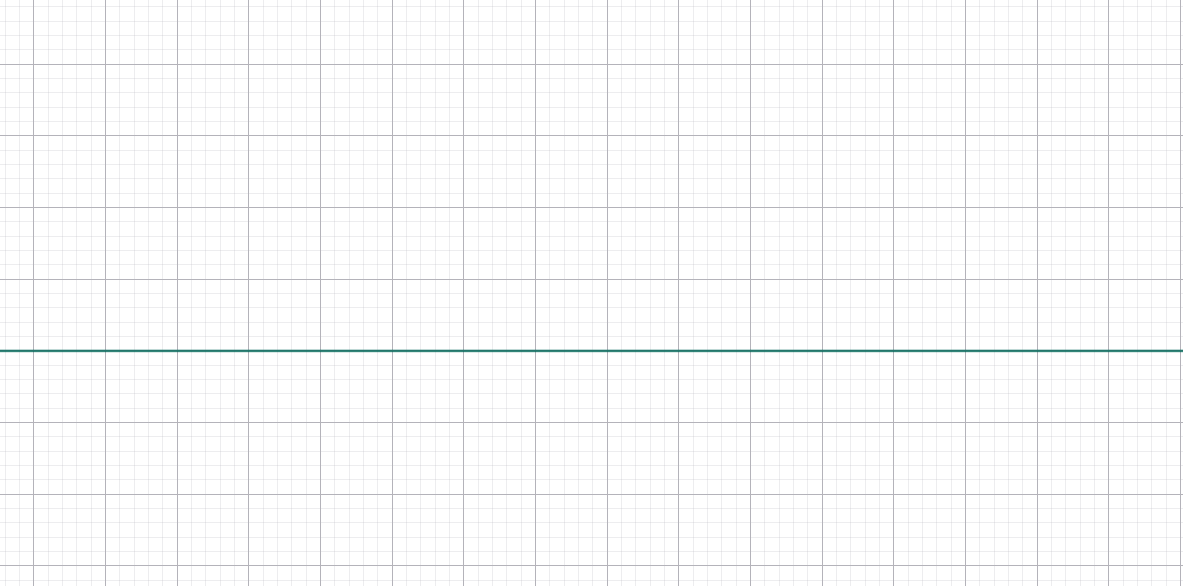

-Peor caso: O(n) (Tiempo lineal). 
Ocurre la primera vez que se consulta un mes n grande que no está en la memoria. El algoritmo se verá obligado a descender recursivamente nivel por nivel hasta alcanzar los casos base y, a partir de allí, comenzar a sumar y guardar los resultados paso a paso para llenar el diccionario con los n meses.
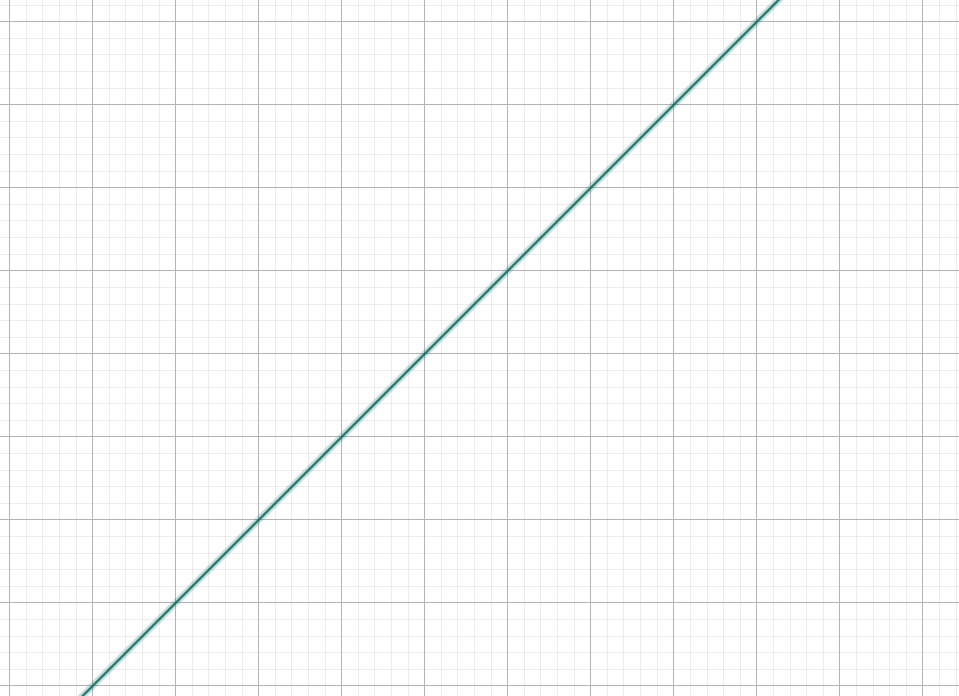

## 6) Código funcional **[15 pts]**


In [ ]:
def calcular_suscriptores(n: int) -> int:

   if not isinstance(n, int):
       return None
   if n < 0:
       return None
   memoria_cache = {}

   def recursividad_memo(mes: int) -> int:
       if mes in memoria_cache:
           return memoria_cache[mes]
       if mes == 0:
           return 0
       if mes == 1:
           return 1
       total_suscriptores = recursividad_memo(mes - 1) + recursividad_memo(mes - 2)
       memoria_cache[mes] = total_suscriptores
       return total_suscriptores
   return recursividad_memo(n)

if __name__ == "__main__":
   mes_prueba = 12
   print(f"Los nuevos suscriptores en el mes {mes_prueba} son: {calcular_suscriptores(mes_prueba)}")



Los nuevos suscriptores en el mes 12 son: 144


## 7) Tests aplicados **[15 pts]**

In [4]:
# Verificación de casos base
assert calcular_suscriptores(0) == 0, "Fallo en el caso base 0"
assert calcular_suscriptores(1) == 1, "Fallo en el caso base 1"
# Verificación de los primeros meses a mano
assert calcular_suscriptores(2) == 1
assert calcular_suscriptores(3) == 2
assert calcular_suscriptores(4) == 3
assert calcular_suscriptores(5) == 5
assert calcular_suscriptores(10) == 55

mes_lejano = 60
resultado = calcular_suscriptores(mes_lejano)
assert resultado == 1548008755920
print(f"Todas las pruebas pasaron. Suscriptores mes {mes_lejano}: {resultado}")

Todas las pruebas pasaron. Suscriptores mes 60: 1548008755920
